## Compare Scaling:  standard  min-Max  Roburst

In [3]:
import pandas as pd

df = pd.read_csv("Social_Network_Ads.csv")

df.sample(5)

,Age,EstimatedSalary,Purchased
124,41,51000,0
277,49,88000,1
1,35,20000,0
283,52,21000,1
223,60,102000,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [5]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


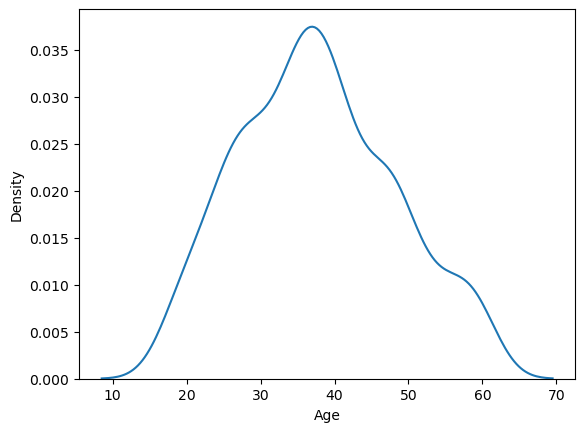

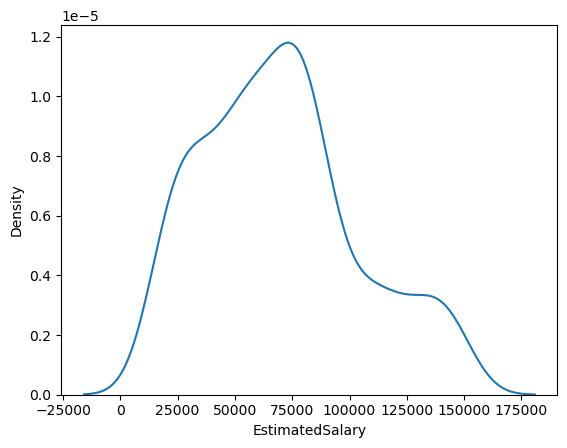

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df['Age'])
plt.show()

sns.kdeplot(df['EstimatedSalary'])
plt.show()



<Axes: xlabel='EstimatedSalary'>

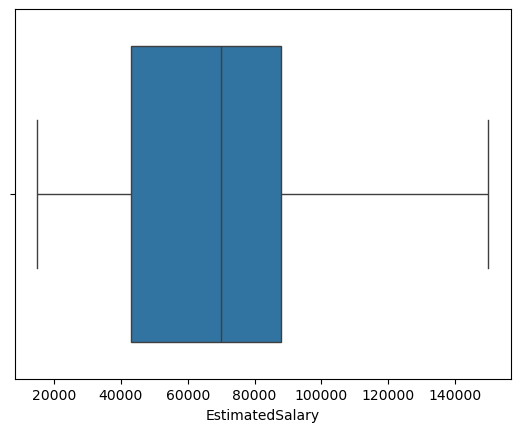

In [11]:
sns.boxplot(x=df['EstimatedSalary'])

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('Purchased', axis=1)
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Min-Max Scaling

In [13]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

X_train_minmax = minmax.fit_transform(X_train)
X_test_minmax = minmax.transform(X_test)

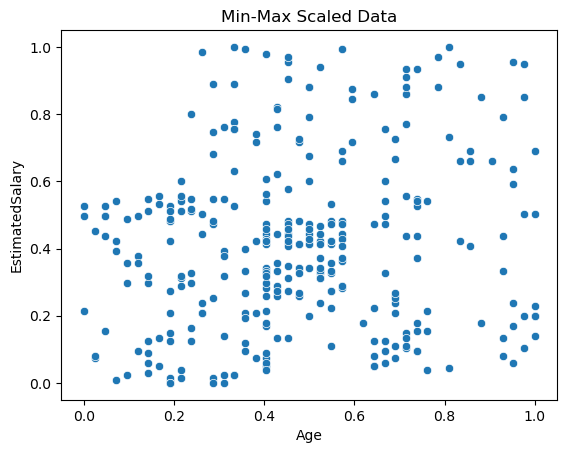

In [19]:
X_train_minmax = pd.DataFrame(X_train_minmax, columns=X_train.columns)

sns.scatterplot(x=X_train_minmax['Age'], y=X_train_minmax['EstimatedSalary'])
plt.title("Min-Max Scaled Data")
plt.show()

## Standard Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

X_train_standard = standard.fit_transform(X_train)
X_test_standard = standard.transform(X_test)

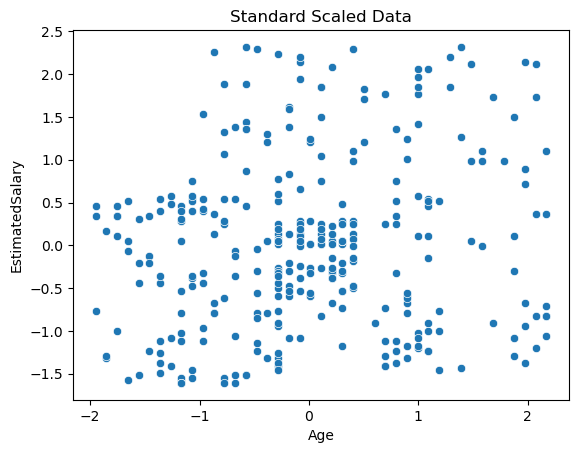

In [18]:
X_train_standard = pd.DataFrame(X_train_standard, columns=X_train.columns)

sns.scatterplot(x=X_train_standard['Age'], y=X_train_standard['EstimatedSalary'])
plt.title("Standard Scaled Data")
plt.show()

## Roburst Scaling

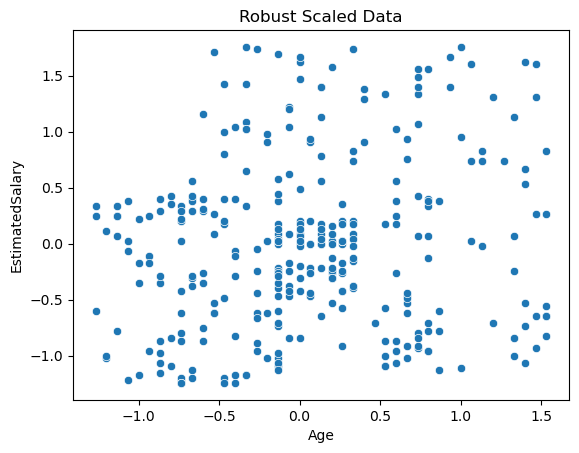

In [22]:
from sklearn.preprocessing import RobustScaler

robust = RobustScaler()

X_train_robust = robust.fit_transform(X_train)
X_test_robust = robust.transform(X_test)

X_train_robust = pd.DataFrame(X_train_robust, columns=X_train.columns)

sns.scatterplot(x=X_train_robust['Age'], y=X_train_robust['EstimatedSalary'])
plt.title("Robust Scaled Data")
plt.show()

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [24]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy without scaling:", accuracy_score(y_test, y_pred))

Accuracy without scaling: 0.825


In [25]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_minmax, y_train)

y_pred = knn.predict(X_test_minmax)

print("Accuracy with MinMax Scaling:", accuracy_score(y_test, y_pred))

Accuracy with MinMax Scaling: 0.925


E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [26]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_standard, y_train)

y_pred = knn.predict(X_test_standard)

print("Accuracy with Standard Scaling:", accuracy_score(y_test, y_pred))

Accuracy with Standard Scaling: 0.9125


E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [27]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_robust, y_train)

y_pred = knn.predict(X_test_robust)

print("Accuracy with Robust Scaling:", accuracy_score(y_test, y_pred))

Accuracy with Robust Scaling: 0.925


E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [28]:
results = {}

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)
results["No Scaling"] = accuracy_score(y_test, knn.predict(X_test))

knn.fit(X_train_minmax, y_train)
results["MinMax"] = accuracy_score(y_test, knn.predict(X_test_minmax))

knn.fit(X_train_standard, y_train)
results["Standard"] = accuracy_score(y_test, knn.predict(X_test_standard))

knn.fit(X_train_robust, y_train)
results["Robust"] = accuracy_score(y_test, knn.predict(X_test_robust))

print(results)

{'No Scaling': 0.825, 'MinMax': 0.925, 'Standard': 0.9125, 'Robust': 0.925}


E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_standard, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [30]:
import numpy as np

x_min, x_max = X_train_standard['Age'].min() - 1, X_train_standard['Age'].max() + 1
y_min, y_max = X_train_standard['EstimatedSalary'].min() - 1, X_train_standard['EstimatedSalary'].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

In [31]:
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

E:\Python\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


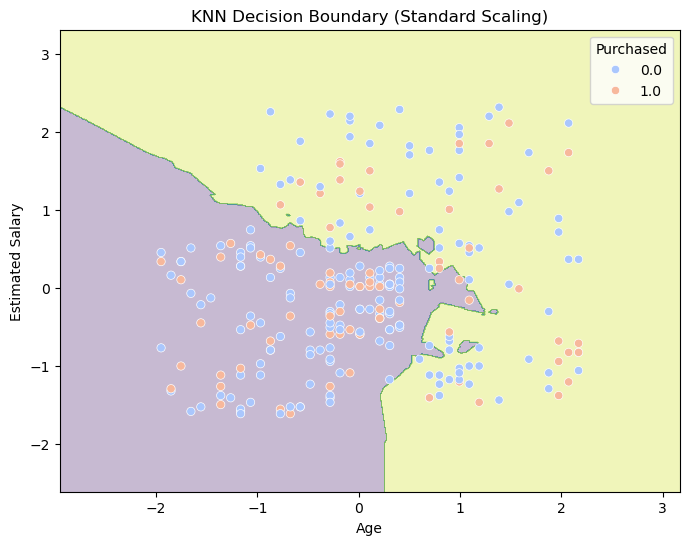

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

sns.scatterplot(
    x=X_train_standard['Age'],
    y=X_train_standard['EstimatedSalary'],
    hue=y_train,
    palette="coolwarm"
)

plt.title("KNN Decision Boundary (Standard Scaling)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")

plt.show()